In [3]:
import yaml
import pandas as pd

def get_schema_dataframe(yaml_path):
    # Đọc file yaml
    with open(yaml_path, 'r', encoding='utf-8') as file:
        schema_data = yaml.safe_load(file)
    
    # Truy cập trực tiếp vào thư mục dữ liệu
    dataset = schema_data.get("Fitabase Data 3.12.16-4.11.16", {})
    if not dataset:
        print("Không tìm thấy dữ liệu cấu hình.")
        return pd.DataFrame()
        
    matrix_data = {}
    table_names = list(dataset.keys())
    
    # Duyệt qua từng bảng và từng cột để map dữ liệu
    for table_name, table_info in dataset.items():
        columns = table_info.get("columns", {})
        for col_name, col_attrs in columns.items():
            col_type = col_attrs.get("type", "unknown")
            row_name = f"{col_name} ({col_type})"
            
            # Khởi tạo row nếu chưa có
            if row_name not in matrix_data:
                matrix_data[row_name] = {t: "" for t in table_names}
            
            # Đánh dấu sự xuất hiện của cột trong bảng
            matrix_data[row_name][table_name] = "✔"
            
    # Tạo DataFrame từ dictionary
    df = pd.DataFrame.from_dict(matrix_data, orient='index')
    df.index.name = "Column Name (Data Type)"
    
    # Sắp xếp theo tên cột theo bảng chữ cái
    df = df.sort_index()
    
    return df

# Thay thế bằng đường dẫn thực tế đến file schema.yaml trong workspace của bạn
file_path = r"D:\NutritionAI_V1\src\api\data_schema\schema.yaml"

# Tạo dataframe
df_columns = get_schema_dataframe(file_path)

# Hiển thị trực tiếp dataframe (chạy trong 1 cell của Jupyter Notebook)
df_columns

,dailyActivity_merged,heartrate_seconds_merged,hourlyCalories_merged,hourlyIntensities_merged,hourlySteps_merged,minuteCaloriesNarrow_merged,minuteIntensitiesNarrow_merged,minuteMETsNarrow_merged,minuteSleep_merged,minuteStepsNarrow_merged,weightLogInfo_merged
Column Name (Data Type),,,,,,,,,,,
ActivityDate (categorical),✔,,,,,,,,,,
ActivityHour (categorical),,,✔,✔,✔,,,,,,
ActivityMinute (categorical),,,,,,✔,✔,✔,,✔,
AverageIntensity (float),,,,✔,,,,,,,
BMI (float),,,,,,,,,,,✔
Calories (float),,,,,,✔,,,,,
Calories (integer),✔,,✔,,,,,,,,
Date (categorical),,,,,,,,,,,✔
FairlyActiveMinutes (integer),✔,,,,,,,,,,


In [8]:
import os
import glob
import json
import pandas as pd

def extract_and_compare_metrics(artifacts_dir):
    # Các chỉ số cần trích xuất theo yêu cầu
    target_keys = [
        "missing_null_ratio", "zero_ratio", "min", "max", "mean", 
        "median_50", "std_dev", "iqr_25_75", "skewness", "kurtosis"
    ]
    
    # Dictionary lưu trữ dữ liệu: {tên_cột: {tên_bảng: {chỉ_số: giá_trị}}}
    col_data = {}
    
    # Quét tất cả các file JSON chứa metrics
    json_pattern = os.path.join(artifacts_dir, '*_metrics.json')
    json_files = glob.glob(json_pattern)
    
    if not json_files:
        print(f"Không tìm thấy file JSON nào trong thư mục {artifacts_dir}")
        return pd.DataFrame()
        
    for file_path in json_files:
        # Lấy tên bảng (bỏ đuôi _metrics.json)
        table_name = os.path.basename(file_path).replace('_metrics.json', '')
        
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                num_metrics = data.get("2_numerical_metrics", {})
                
                for col, metrics in num_metrics.items():
                    if col not in col_data:
                        col_data[col] = {}
                    
                    # Trích xuất các key được yêu cầu
                    extracted = {k: metrics.get(k, None) for k in target_keys}
                    col_data[col][table_name] = extracted
                    
            except Exception as e:
                print(f"❌ Lỗi khi đọc file {file_path}: {e}")

    # Xử lý gộp kết quả
    rows = []
    for col, tables_metrics in col_data.items():
        # Nhóm các bảng có CHỈ SỐ Y HỆT NHAU
        # Dùng tuple của các items để làm key (hashable) cho dictionary
        groups = {}
        for table, metrics in tables_metrics.items():
            metric_hash = tuple((k, metrics[k]) for k in target_keys)
            
            if metric_hash not in groups:
                groups[metric_hash] = []
            groups[metric_hash].append(table)
            
        # Format lại kết quả cho mỗi nhóm
        for metric_hash, tables in groups.items():
            metrics_dict = dict(metric_hash)
            
            # Nếu tất cả các bảng chứa cột này đều có chung chỉ số
            if len(tables) == len(tables_metrics) and len(tables_metrics) > 1:
                 table_display = "TẤT CẢ các bảng chứa cột này"
            else:
                 # Nếu khác nhau hoặc chỉ có 1 bảng, liệt kê rõ tên bảng
                 table_display = ", ".join(tables)
                 
            # Tạo dòng dữ liệu
            row = {
                "Column Name": col,
                "Tables (Source)": table_display
            }
            row.update(metrics_dict)
            rows.append(row)
            
    # Chuyển thành DataFrame và sắp xếp
    df = pd.DataFrame(rows)
    df = df.sort_values(by=["Column Name", "Tables (Source)"]).reset_index(drop=True)
    
    return df

# --- CÁCH SỬ DỤNG ---
# Thay 'Artifacts' bằng đường dẫn thực tế chứa các file json của bạn
artifacts_folder = r"D:\NutritionAI_V1\Artifacts" 
df_metrics = extract_and_compare_metrics(artifacts_folder)

# Tùy chỉnh hiển thị Pandas để không bị ẩn cột/dòng trong Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

# In ra kết quả
df_metrics

,Column Name,Tables (Source),missing_null_ratio,zero_ratio,min,max,mean,median_50,std_dev,iqr_25_75,skewness,kurtosis
0,AverageIntensity,hourlyIntensities_merged,0.0,0.439800,0.000000e+00,2.900000e+00,1.728133e-01,3.333300e-02,3.097545e-01,2.333330e-01,3.551888,17.732111
1,BMI,weightLogInfo_merged,0.0,0.000000,2.145000e+01,4.617000e+01,2.573091e+01,2.439000e+01,4.330387e+00,1.660000e+00,3.756692,16.308065
2,Calories,dailyActivity_merged,0.0,0.000000,5.000000e+01,4.562000e+03,2.213673e+03,2.069000e+03,7.865459e+02,8.995000e+02,0.413723,0.384420
3,Calories,hourlyCalories_merged,0.0,0.000000,4.200000e+01,5.380000e+02,8.330430e+01,7.000000e+01,4.788007e+01,3.700000e+01,3.571663,19.471389
4,Calories,minuteCaloriesNarrow_merged,0.0,0.000000,7.973000e-01,7.893270e+00,1.418648e+00,9.567600e-01,1.262753e+00,1.597400e-01,2.717154,7.250353
5,FairlyActiveMinutes,dailyActivity_merged,0.0,0.491150,0.000000e+00,6.600000e+02,1.321460e+01,2.000000e+00,3.638249e+01,1.600000e+01,12.975078,222.707900
6,Id,dailyActivity_merged,0.0,0.000000,1.503960e+09,8.877689e+09,4.621684e+09,4.057193e+09,2.297523e+09,4.140615e+09,0.355624,-1.041001
7,Id,heartrate_seconds_merged,0.0,0.000000,2.022484e+09,2.022484e+09,2.022484e+09,2.022484e+09,0.000000e+00,0.000000e+00,0.000000,0.000000
8,Id,"hourlyCalories_merged, hourlyIntensities_merge...",0.0,0.000000,1.503960e+09,4.057193e+09,2.475035e+09,2.026352e+09,8.696687e+08,1.528363e+09,0.780004,-0.865368
9,Id,"minuteCaloriesNarrow_merged, minuteIntensities...",0.0,0.000000,1.503960e+09,1.503960e+09,1.503960e+09,1.503960e+09,0.000000e+00,0.000000e+00,0.000000,0.000000


In [10]:
import os
import glob
import json
import pandas as pd

def select_features_and_save_json(artifacts_dir, output_json_path="selected_features_config.json", multicol_threshold=0.85):
    json_pattern = os.path.join(artifacts_dir, '*_metrics.json')
    json_files = glob.glob(json_pattern)
    
    if not json_files:
        print(f"Không tìm thấy file JSON nào trong thư mục {artifacts_dir}")
        return
        
    master_feature_selection = {}
    
    for file_path in json_files:
        table_name = os.path.basename(file_path).replace('_metrics.json', '')
        
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                relationships = data.get("4_relationships", {})
                
                # Ưu tiên dùng pearson_correlation, fallback sang spearman nếu không có
                corr_matrix = relationships.get("pearson_correlation", {})
                if not corr_matrix:
                    corr_matrix = relationships.get("spearman_correlation", {})
                    
                if not corr_matrix or "Calories" not in corr_matrix:
                    continue
                
                cols = list(corr_matrix.keys())
                
                # 1. Phát hiện các cặp đa cộng tuyến >= threshold
                dropped_due_to_multicol = set()
                for i in range(len(cols)):
                    for j in range(i + 1, len(cols)):
                        c1, c2 = cols[i], cols[j]
                        if c1 == "Calories" or c2 == "Calories":
                            continue
                            
                        val = corr_matrix[c1].get(c2, 0)
                        if val is not None and abs(val) >= multicol_threshold:
                            # Giữ lại cột có độ tương quan với Calories cao hơn, loại bỏ cột còn lại
                            corr_c1 = abs(corr_matrix["Calories"].get(c1, 0) or 0)
                            corr_c2 = abs(corr_matrix["Calories"].get(c2, 0) or 0)
                            
                            if corr_c1 >= corr_c2:
                                dropped_due_to_multicol.add(c2)
                            else:
                                dropped_due_to_multicol.add(c1)
                
                # 2. Lọc các cột giữ lại (loại bỏ cột đa cộng tuyến và chính biến mục tiêu Calories, Id, Date nếu có)
                retained_columns = []
                calories_corr_scores = {}
                
                for col in cols:
                    if col in ["Calories", "Id", "ActivityDate", "Date", "Time"]:
                        continue
                    if col in dropped_due_to_multicol:
                        continue
                        
                    retained_columns.append(col)
                    calories_corr_scores[col] = corr_matrix["Calories"].get(col, 0)
                
                # Sắp xếp các cột giữ lại theo độ tương quan giảm dần với Calories
                sorted_retained = sorted(
                    retained_columns, 
                    key=lambda x: abs(calories_corr_scores.get(x, 0) or 0), 
                    reverse=True
                )
                
                master_feature_selection[table_name] = {
                    "retained_features": sorted_retained,
                    "dropped_due_to_multicollinearity": list(dropped_due_to_multicol),
                    "correlation_with_calories": {col: calories_corr_scores[col] for col in sorted_retained}
                }
                
            except Exception as e:
                print(f"❌ Lỗi khi xử lý file {file_path}: {e}")

    # Ghi kết quả ra file JSON
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(master_feature_selection, f, ensure_ascii=False, indent=4)
        
    print(f"✅ Đã xuất thành công danh sách tính năng tối ưu ra file: {output_json_path}")

if __name__ == "__main__":
    artifacts_folder = "D:\\NutritionAI_V1\\Artifacts\\EDA_reports"
    output_file = "D:\\NutritionAI_V1\\Artifacts\\choose_features\\Calories_features_config.json"
    
    # Chạy hàm với ngưỡng đa cộng tuyến 0.85
    select_features_and_setup_config = select_features_and_save_json(
        artifacts_dir=artifacts_folder, 
        output_json_path=output_file, 
        multicol_threshold=0.85
    )

✅ Đã xuất thành công danh sách tính năng tối ưu ra file: D:\NutritionAI_V1\Artifacts\choose_features\Calories_features_config.json


# copy to staging

In [10]:
import os
import sys
import yaml

# --- 1. SỬA LỖI IMPORTS & MODULE PATH ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.postgres.core.connection import get_connection

# --- 2. CẤU HÌNH SCHEMA VÀ ĐƯỜNG DẪN ---
YAML_PATH = r"D:\NutritionAI_V1\src\api\data_schema\schema.yaml"
SOURCE_SCHEMA = "raw"
TARGET_SCHEMA = "staging"


# --- 3. ĐỌC DANH SÁCH BẢNG TỪ SCHEMA.YAML ---
def get_tables_from_schema(yaml_path):
    with open(yaml_path, "r", encoding="utf-8") as file:
        schema_data = yaml.safe_load(file)

    dataset = schema_data.get("Fitabase Data 3.12.16-4.11.16", {})
    if not dataset:
        print(
            "❌ Không tìm thấy key 'Fitabase Data 3.12.16-4.11.16' trong schema."
        )
        return []

    return list(dataset.keys())


# --- 4. TẠO SCHEMA STAGING NẾU CHƯA TỒN TẠI ---
with get_connection() as conn:
    # LƯU Ý: Bỏ hàm text() đi, dùng string trực tiếp cho psycopg
    conn.execute(f"CREATE SCHEMA IF NOT EXISTS {TARGET_SCHEMA};")
    conn.commit()


# --- 5. COPY DỮ LIỆU BẰNG SQL TRỰC TIẾP ---
tables = get_tables_from_schema(YAML_PATH)

with get_connection() as conn:
    for table_name in tables:
        print(
            f"🔄 Đang copy {SOURCE_SCHEMA}.{table_name} -> {TARGET_SCHEMA}.{table_name}..."
        )

        try:
            # LƯU Ý: Bỏ hàm text() đi
            copy_query = f"""
                DROP TABLE IF EXISTS "{TARGET_SCHEMA}"."{table_name}";
                CREATE TABLE "{TARGET_SCHEMA}"."{table_name}" AS 
                SELECT * FROM "{SOURCE_SCHEMA}"."{table_name}";
            """

            conn.execute(copy_query)
            conn.commit()

            # Lấy số dòng đã copy (Với raw psycopg, dùng fetchone()[0] thay vì scalar())
            count_query = f'SELECT COUNT(*) FROM "{TARGET_SCHEMA}"."{table_name}";'
            
            # Fetchone trả về tuple ví dụ (150,), fetchone()[0] để lấy số 150
            row_count = conn.execute(count_query).fetchone()[0]

            print(
                f"✅ Đã copy thành công {row_count:,} dòng vào {TARGET_SCHEMA}.{table_name}"
            )

        except Exception as e:
            conn.rollback()
            print(f"❌ Lỗi khi copy bảng {table_name}: {e}")

print("\n🎉 Hoàn thành chuyển toàn bộ dữ liệu từ raw sang staging!")

🔄 Đang copy raw.dailyActivity_merged -> staging.dailyActivity_merged...
✅ Đã copy thành công 452 dòng vào staging.dailyActivity_merged
🔄 Đang copy raw.heartrate_seconds_merged -> staging.heartrate_seconds_merged...
✅ Đã copy thành công 1,154,681 dòng vào staging.heartrate_seconds_merged
🔄 Đang copy raw.hourlyCalories_merged -> staging.hourlyCalories_merged...
✅ Đã copy thành công 24,084 dòng vào staging.hourlyCalories_merged
🔄 Đang copy raw.hourlyIntensities_merged -> staging.hourlyIntensities_merged...
✅ Đã copy thành công 24,084 dòng vào staging.hourlyIntensities_merged
🔄 Đang copy raw.hourlySteps_merged -> staging.hourlySteps_merged...
✅ Đã copy thành công 24,084 dòng vào staging.hourlySteps_merged
🔄 Đang copy raw.minuteCaloriesNarrow_merged -> staging.minuteCaloriesNarrow_merged...
✅ Đã copy thành công 1,445,040 dòng vào staging.minuteCaloriesNarrow_merged
🔄 Đang copy raw.minuteIntensitiesNarrow_merged -> staging.minuteIntensitiesNarrow_merged...
✅ Đã copy thành công 1,445,040 dòng

## standing the time and add prameters


In [11]:
import os
import sys

# --- 1. SỬA LỖI IMPORTS & MODULE PATH ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.postgres.core.connection import get_connection

TARGET_SCHEMA = "staging"

# Danh sách các cột cần chuyển đổi
TARGET_COLUMNS = [
    "ActivityDate",
    "ActivityHour",
    "ActivityMinute",
    "Date",
    "Time",
    "date"
]

with get_connection() as conn:
    for col in TARGET_COLUMNS:
        # Lấy danh sách các bảng trong schema staging có chứa cột này
        find_tables_query = f"""
            SELECT table_name 
            FROM information_schema.columns 
            WHERE table_schema = '{TARGET_SCHEMA}' 
              AND column_name = '{col}';
        """
        
        tables = [row[0] for row in conn.execute(find_tables_query).fetchall()]
        
        for table in tables:
            print(f"🔄 Đang format cột '{col}' trong bảng {TARGET_SCHEMA}.{table}...")
            try:
                # Cập nhật format: Ép kiểu string hiện tại về timestamp, sau đó format sang MM/DD/YY
                update_query = f"""
                    UPDATE "{TARGET_SCHEMA}"."{table}"
                    SET "{col}" = to_char("{col}"::timestamp, 'MM/DD/YY')
                    WHERE "{col}" IS NOT NULL;
                """
                
                conn.execute(update_query)
                conn.commit()
                print(f"✅ Thành công: '{col}' trong '{table}'")
                
            except Exception as e:
                conn.rollback()
                print(f"❌ Lỗi khi format '{col}' trong '{table}': {e}")

print("\n🎉 Hoàn thành chuyển đổi format thời gian!")

🔄 Đang format cột 'ActivityDate' trong bảng staging.dailyActivity_merged...
✅ Thành công: 'ActivityDate' trong 'dailyActivity_merged'
🔄 Đang format cột 'ActivityHour' trong bảng staging.hourlyCalories_merged...
✅ Thành công: 'ActivityHour' trong 'hourlyCalories_merged'
🔄 Đang format cột 'ActivityHour' trong bảng staging.hourlyIntensities_merged...
✅ Thành công: 'ActivityHour' trong 'hourlyIntensities_merged'
🔄 Đang format cột 'ActivityHour' trong bảng staging.hourlySteps_merged...
✅ Thành công: 'ActivityHour' trong 'hourlySteps_merged'
🔄 Đang format cột 'ActivityMinute' trong bảng staging.minuteIntensitiesNarrow_merged...
✅ Thành công: 'ActivityMinute' trong 'minuteIntensitiesNarrow_merged'
🔄 Đang format cột 'ActivityMinute' trong bảng staging.minuteMETsNarrow_merged...
✅ Thành công: 'ActivityMinute' trong 'minuteMETsNarrow_merged'
🔄 Đang format cột 'ActivityMinute' trong bảng staging.minuteStepsNarrow_merged...
✅ Thành công: 'ActivityMinute' trong 'minuteStepsNarrow_merged'
🔄 Đang for

In [13]:
import os
import sys
import pandas as pd
import numpy as np

# --- SỬA LỖI IMPORTS VÀ MODULE PATH ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.postgres.core.connection import get_connection

TARGET_SCHEMA = "staging"

# Danh sách các cột thời gian đã chuẩn hóa có thể dùng để Group By
TIME_COLUMNS = ["ActivityDate", "ActivityHour", "ActivityMinute", "Date", "Time", "date"]

# Hàm lấy danh sách bảng (ĐÃ BỎ text())
def get_tables_from_db(schema_name):
    with get_connection() as conn:
        query = f"SELECT table_name FROM information_schema.tables WHERE table_schema = '{schema_name}';"
        return [row[0] for row in conn.execute(query).fetchall()]

tables = get_tables_from_db(TARGET_SCHEMA)

for table in tables:
    print(f"\n{'='*50}")
    print(f"🔄 Đang xử lý bảng: {TARGET_SCHEMA}.{table}")
    print(f"{'='*50}")
    
    try:
        # 1. Đọc dữ liệu từ DB
        # Pandas có thể hiện cảnh báo (Warning) khi dùng raw psycopg connection, nhưng vẫn sẽ chạy được.
        # Để pandas hoạt động trơn tru nhất với psycopg3, tốt nhất là mở kết nối riêng cho nó:
        with get_connection() as conn:
            query = f'SELECT * FROM "{TARGET_SCHEMA}"."{table}"'
            df = pd.read_sql(query, con=conn)
        
        if df.empty:
            print("⚠️ Bảng rỗng, bỏ qua.")
            continue
            
        # 2. Xác định các cột dùng để Group By (Id + các cột thời gian có mặt trong bảng)
        group_cols = ['Id'] if 'Id' in df.columns else []
        group_cols += [col for col in TIME_COLUMNS if col in df.columns]
        
        if not group_cols:
            print("⚠️ Không tìm thấy cột 'Id' hoặc cột thời gian nào để Group By. Bỏ qua.")
            continue
            
        # 3. Xác định các cột Numeric để tính toán (loại bỏ các cột đang dùng để group by)
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [col for col in numeric_cols if col not in group_cols]
        
        if not numeric_cols:
            print("⚠️ Không có cột numeric nào để tính toán. Bỏ qua.")
            continue

        # 4. Định nghĩa hàm thống kê (tùy chỉnh theo tên bảng)
        current_agg_funcs = {
            'mean': 'mean',
            'median': 'median',
            'mode': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
            'std': 'std',
            'var': 'var',
            'min': 'min',
            'max': 'max',
            'q1': lambda x: x.quantile(0.25),
            'q3': lambda x: x.quantile(0.75),
            'skewness': lambda x: x.skew(),
            'kurtosis': lambda x: x.kurt()
        }
        
        # Xóa skewness và kurtosis cho 2 bảng đặc thù
        if table in ['dailyActivity_merged', 'weightLogInfo_merged']:
            current_agg_funcs.pop('skewness', None)
            current_agg_funcs.pop('kurtosis', None)
            
        # Tạo dictionary ánh xạ: { 'Cột_A': [('mean', 'mean'), ('mode', <lambda>), ...] }
        agg_dict = {
            col: [(k, v) for k, v in current_agg_funcs.items()] 
            for col in numeric_cols
        }
        
        # 5. Thực hiện Group By và Aggregation
        df_grouped = df.groupby(group_cols).agg(agg_dict)
        
        # 6. Làm phẳng MultiIndex Columns
        df_grouped.columns = [f"{col}_{stat}" for col, stat in df_grouped.columns]
        
        # Reset index để biến các cột Group By trở lại thành cột dữ liệu bình thường
        df_grouped = df_grouped.reset_index()
        
        print(f"✅ Đã group by thành công dựa trên: {group_cols}")
        print(f"📊 Kích thước bảng sau khi tính toán: {df_grouped.shape}")
        
        # Hiển thị 2 dòng đầu tiên
        display(df_grouped.head(2))
        
    except Exception as e:
        print(f"❌ Lỗi khi xử lý bảng {table}: {e}")


🔄 Đang xử lý bảng: staging.minuteIntensitiesNarrow_merged


C:\Users\admin\AppData\Local\Temp\ipykernel_13528\441260907.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=conn)


✅ Đã group by thành công dựa trên: ['Id', 'ActivityMinute']
📊 Kích thước bảng sau khi tính toán: (1021, 13)


,Id,ActivityMinute,Intensity_mean,Intensity_median,Intensity_mode,Intensity_std,Intensity_var,Intensity_min,Intensity_max,Intensity_q1,Intensity_q3,Intensity_skewness,Intensity_kurtosis
0,1503960366,03/12/16,0.413889,0.0,0,0.817343,0.668049,0,3,0.0,1.0,2.166936,3.903093
1,1503960366,03/13/16,0.386806,0.0,0,0.832601,0.693224,0,3,0.0,0.0,2.307782,4.312036



🔄 Đang xử lý bảng: staging.minuteMETsNarrow_merged


...

,Id,ActivityHour,StepTotal_mean,StepTotal_median,StepTotal_mode,StepTotal_std,StepTotal_var,StepTotal_min,StepTotal_max,StepTotal_q1,StepTotal_q3,StepTotal_skewness,StepTotal_kurtosis
0,1503960366,03/12/16,819.791667,154.5,0,1333.925556,1.779357e+06,0,4919,0.0,1061.5,2.259889,4.902272
1,1503960366,03/13/16,712.750000,84.5,0,1349.487383,1.821116e+06,0,4854,4.5,510.0,2.241022,4.247101



🔄 Đang xử lý bảng: staging.minuteCaloriesNarrow_merged


C:\Users\admin\AppData\Local\Temp\ipykernel_13528\441260907.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=conn)


✅ Đã group by thành công dựa trên: ['Id', 'ActivityMinute']
📊 Kích thước bảng sau khi tính toán: (1021, 13)


,Id,ActivityMinute,Calories_mean,Calories_median,Calories_mode,Calories_std,Calories_var,Calories_min,Calories_max,Calories_q1,Calories_q3,Calories_skewness,Calories_kurtosis
0,1503960366,03/12/16,1.546983,0.7973,0.7973,1.470173,2.161409,0.7973,7.89327,0.7973,1.91352,2.317210,4.584738
1,1503960366,03/13/16,1.458948,0.7973,0.7973,1.388260,1.927266,0.7973,7.17570,0.7973,0.95676,2.502599,5.330644


In [6]:
from sqlalchemy import create_engine, text

# Giả sử engine đã được khởi tạo từ các bước trước của bạn
# engine = create_engine(db_url)

try:
    with engine.begin() as conn:
        # 1. Xóa cột 'Fat' khỏi bảng weightLogInfo_merged trong schema raw
        drop_fat_query = text("""
            ALTER TABLE "raw"."weightLogInfo_merged" 
            DROP COLUMN IF EXISTS "Fat";
        """)
        conn.execute(drop_fat_query)
        print("✅ Đã xóa thành công cột 'Fat' trong bảng weightLogInfo_merged trên PostgreSQL.")
        
        # 2. Xóa các dòng có Calories == 0 khỏi bảng dailyActivity_merged trong schema raw
        delete_zero_calories_query = text("""
            DELETE FROM "raw"."dailyActivity_merged" 
            WHERE "Calories" = 0;
        """)
        result = conn.execute(delete_zero_calories_query)
        print(f"✅ Đã loại bỏ các bản ghi có Calories == 0 trong bảng dailyActivity_merged trên PostgreSQL.")

except Exception as e:
    print(f"❌ Lỗi khi thực hiện làm sạch dữ liệu trên CSDL: {e}")

✅ Đã xóa thành công cột 'Fat' trong bảng weightLogInfo_merged trên PostgreSQL.
✅ Đã loại bỏ các bản ghi có Calories == 0 trong bảng dailyActivity_merged trên PostgreSQL.


# EDA

In [17]:
df.head(5)  # Hiển thị 5 dòng đầu tiên của DataFrame

steps  calories_burned  distance_km  active_minutes  \
user_id date                                                              
1       2023-01-02  21559          3045.06         0.32             841   
        2023-01-03   1762          3606.03         9.77             567   
        2023-01-05  21471          2593.82         5.05            1297   
        2023-01-06   4195          3364.94         6.76             932   
        2023-01-08  29530          1988.14        17.90             694   

                    sleep_hours  heart_rate_avg workout_type  \
user_id date                                                   
1       2023-01-02         11.5             126      Cycling   
        2023-01-03          5.4              76      Cycling   
        2023-01-05          8.2             175      Walking   
        2023-01-06          3.1             122     Swimming   
        2023-01-08         10.0              60      Cycling   

                   weather_conditions      mood  weather_conditions_encoded  \
user_id date                                                                  
1       2023-01-02               Rain  Stressed                           1   
        2023-01-03              Clear   Neutral                           3   
        2023-01-05              Clear     Happy                           3   
        2023-01-06               Rain     Tired                           1   
        2023-01-08              Clear   Neutral                           3   

                    workout_type_encoded  mood_encoded  location_Gym  \
user_id date                                                           
1       2023-01-02                     4             0           0.0   
        2023-01-03                     4             2           1.0   
        2023-01-05                     2             3           0.0   
        2023-01-06                     5             1           0.0   
        2023-01-08                     4             2           0.0   

                    location_Home  location_Office  location_Other  \
user_id date                                                         
1       2023-01-02            0.0              0.0             0.0   
        2023-01-03            0.0              0.0             0.0   
        2023-01-05            0.0              0.0             0.0   
        2023-01-06            0.0              1.0             0.0   
        2023-01-08            0.0              1.0             0.0   

                    location_Park  
user_id date                       
1       2023-01-02            1.0  
        2023-01-03            0.0  
        2023-01-05            1.0  
        2023-01-06            0.0  
        2023-01-08            0.0

In [10]:
import numpy as np

# Count zero values per column
zero_counts = (df == 0).sum()
print("Zero counts per column:\n", zero_counts)

# Zero counts for numeric columns only
numeric_zero_counts = (df.select_dtypes(include=[np.number]) == 0).sum()
print("\nZero counts (numeric columns):\n", numeric_zero_counts)

Zero counts per column:
 user_id               0
date                  0
steps                 0
calories_burned       0
distance_km           0
active_minutes        0
sleep_hours           0
heart_rate_avg        0
workout_type          0
weather_conditions    0
location              0
mood                  0
dtype: int64

Zero counts (numeric columns):
 user_id            0
steps              0
calories_burned    0
distance_km        0
active_minutes     0
sleep_hours        0
heart_rate_avg     0
dtype: int64


In [3]:
# delete all rows where any column has a zero value

df = df[(df != 0).all(axis=1)]

In [13]:
# Lấy các cột kiểu object và loại bỏ cột 'date'
categorical_columns = [col for col in df.select_dtypes(include=['object']).columns if col != 'date']

for column in categorical_columns:
    unique_values = df[column].unique()
    print(f"Column: {column}, Unique Values: {unique_values}")

Column: workout_type, Unique Values: ['Walking' 'Cycling' 'Yoga' 'Swimming' 'Gym Workout' 'Running' 'None']
Column: weather_conditions, Unique Values: ['Clear' 'Fog' 'Snow' 'Rain']
Column: location, Unique Values: ['Park' 'Office' 'Home' 'Gym' 'Other']
Column: mood, Unique Values: ['Tired' 'Happy' 'Neutral' 'Stressed']


In [4]:
# 1. Đảm bảo cột date ở định dạng datetime và sắp xếp theo thời gian
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['user_id', 'date'])

# 2. Thiết lập MultiIndex
df = df.set_index(['user_id', 'date'])

In [5]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# ==========================================
# 1. ĐỊNH NGHĨA MAPPING CHO ORDINAL ENCODING
# ==========================================
weather_mapping = {
    'Snow': 0,
    'Rain': 1,
    'Fog': 2,
    'Clear': 3
}

workout_mapping = {
    'None': 0,
    'Yoga': 1,
    'Walking': 2,
    'Gym Workout': 3,
    'Cycling': 4,
    'Swimming': 5,
    'Running': 6
}

mood_mapping = {
    'Stressed': 0,
    'Tired': 1,
    'Neutral': 2,
    'Happy': 3
}

# Tạo Reverse Mapping (Từ điển đảo ngược: số -> chữ) để truy vấn lại sau này
reverse_weather_mapping = {v: k for k, v in weather_mapping.items()}
reverse_workout_mapping = {v: k for k, v in workout_mapping.items()}
reverse_mood_mapping = {v: k for k, v in mood_mapping.items()}

# ==========================================
# 2. THỰC HIỆN ENCODING VÀ XÓA CỘT CŨ
# ==========================================


# --- 2.1 Ordinal Encoding ---
df['weather_conditions_encoded'] = df['weather_conditions'].map(weather_mapping)
df['workout_type_encoded'] = df['workout_type'].map(workout_mapping)
df['mood_encoded'] = df['mood'].map(mood_mapping)

# --- 2.2 One-Hot Encoding cho location ---
encoder = OneHotEncoder(sparse_output=False)
encoded_location = encoder.fit_transform(df[['location']])
location_column_names = encoder.get_feature_names_out(['location'])
df[location_column_names] = encoded_location

# --- 2.3 Xóa toàn bộ các cột chữ (kế thừa cũ) ---
cols_to_drop = ['weather_conditions', 'workout_type', 'mood', 'location']
df = df.drop(columns=cols_to_drop)

print("--- DATAFRAME SAU KHI MÃ HÓA VÀ XÓA CỘT CŨ ---")
print(df)
print("\n" + "="*50 + "\n")

# ==========================================
# 3. TRUY VẤN/GIẢI MÃ LẠI Ý NGHĨA BAN ĐẦU
# ==========================================

# --- Cách 1: Giải mã thủ công 1 giá trị đơn lẻ ---
sample_weather_code = df['weather_conditions_encoded'].iloc[0]
original_weather = reverse_weather_mapping[sample_weather_code]
print(f"Mã thời tiết: {sample_weather_code} -> Ý nghĩa ban đầu: '{original_weather}'")

# --- Cách 2: Giải mã ngược cho OneHotEncoder ---
# Lấy lại giá trị location ban đầu từ các cột One-Hot
decoded_locations = encoder.inverse_transform(df[location_column_names])
print(f"Giải mã cột location từ OneHot: {decoded_locations.flatten()}")


# --- Cách 3: Hàm tiện ích khôi phục các cột chữ gốc từ dữ liệu đã Encode ---
def decode_dataframe(encoded_df, encoder_ohe, location_cols):
    """
    Hàm khôi phục lại các cột văn bản gốc từ DataFrame đã mã hóa.
    """
    decoded_df = encoded_df.copy()
    
    # Khôi phục Ordinal Columns
    decoded_df['weather_conditions'] = decoded_df['weather_conditions_encoded'].map(reverse_weather_mapping)
    decoded_df['workout_type'] = decoded_df['workout_type_encoded'].map(reverse_workout_mapping)
    decoded_df['mood'] = decoded_df['mood_encoded'].map(reverse_mood_mapping)
    
    # Khôi phục One-Hot Column
    decoded_df['location'] = encoder_ohe.inverse_transform(decoded_df[location_cols]).flatten()
    
    return decoded_df

# Ví dụ khôi phục lại dữ liệu gốc
restored_df = decode_dataframe(df, encoder, location_column_names)
print("\n--- DATAFRAME ĐÃ ĐƯỢC GIẢI MÃ LẠI Ý NGHĨA BAN ĐẦU ---")
print(restored_df[['weather_conditions', 'workout_type', 'mood', 'location']])

--- DATAFRAME SAU KHI MÃ HÓA VÀ XÓA CỘT CŨ ---
                    steps  calories_burned  distance_km  active_minutes  \
user_id date                                                              
1       2023-01-02  21559          3045.06         0.32             841   
        2023-01-03   1762          3606.03         9.77             567   
        2023-01-05  21471          2593.82         5.05            1297   
        2023-01-06   4195          3364.94         6.76             932   
        2023-01-08  29530          1988.14        17.90             694   
...                   ...              ...          ...             ...   
999     2025-09-22  15220          3828.10         5.87             661   
        2025-09-22  19069          1937.66         6.42             974   
        2025-09-24  29005          3787.88         7.40             271   
        2025-09-26  12226          3758.45         5.69             806   
        2025-09-26  20600          2986.77        16.

In [23]:
df.describe()

,steps,calories_burned,distance_km,active_minutes,sleep_hours,heart_rate_avg,weather_conditions_encoded,workout_type_encoded,mood_encoded,location_Gym,location_Home,location_Office,location_Other,location_Park
count,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000,995025.000000
mean,15008.696581,2749.998421,9.997281,719.874819,6.024665,119.454160,1.500321,2.999591,1.500850,0.199849,0.200558,0.200006,0.199961,0.199626
std,8659.038438,721.495357,5.772756,415.616711,3.449833,34.654471,1.117666,1.999900,1.118794,0.399887,0.400418,0.400005,0.399971,0.399720
min,1.000000,1500.000000,0.010000,1.000000,0.100000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7496.000000,2125.440000,4.990000,359.000000,3.000000,89.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15023.000000,2748.300000,10.000000,720.000000,6.000000,119.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,22511.000000,3375.200000,14.990000,1080.000000,9.000000,149.000000,2.000000,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,29999.000000,4000.000000,20.000000,1439.000000,12.000000,179.000000,3.000000,6.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Ma trận tương quan:
                                steps  calories_burned  distance_km  \
steps                       1.000000         0.000038     0.000660   
calories_burned             0.000038         1.000000     0.000050   
distance_km                 0.000660         0.000050     1.000000   
active_minutes             -0.000175         0.000408     0.001889   
sleep_hours                -0.001375        -0.002027     0.000385   
heart_rate_avg             -0.001602        -0.000261    -0.000061   
weather_conditions_encoded  0.000523         0.001203    -0.000223   
workout_type_encoded        0.000043         0.001608    -0.001129   
mood_encoded               -0.002391         0.000974    -0.001489   
location_Gym                0.000881         0.000512    -0.001014   
location_Home              -0.001885        -0.000682     0.001056   
location_Office            -0.000269         0.001350    -0.000429   
location_Other              0.001045        -0.001116     0.000140   

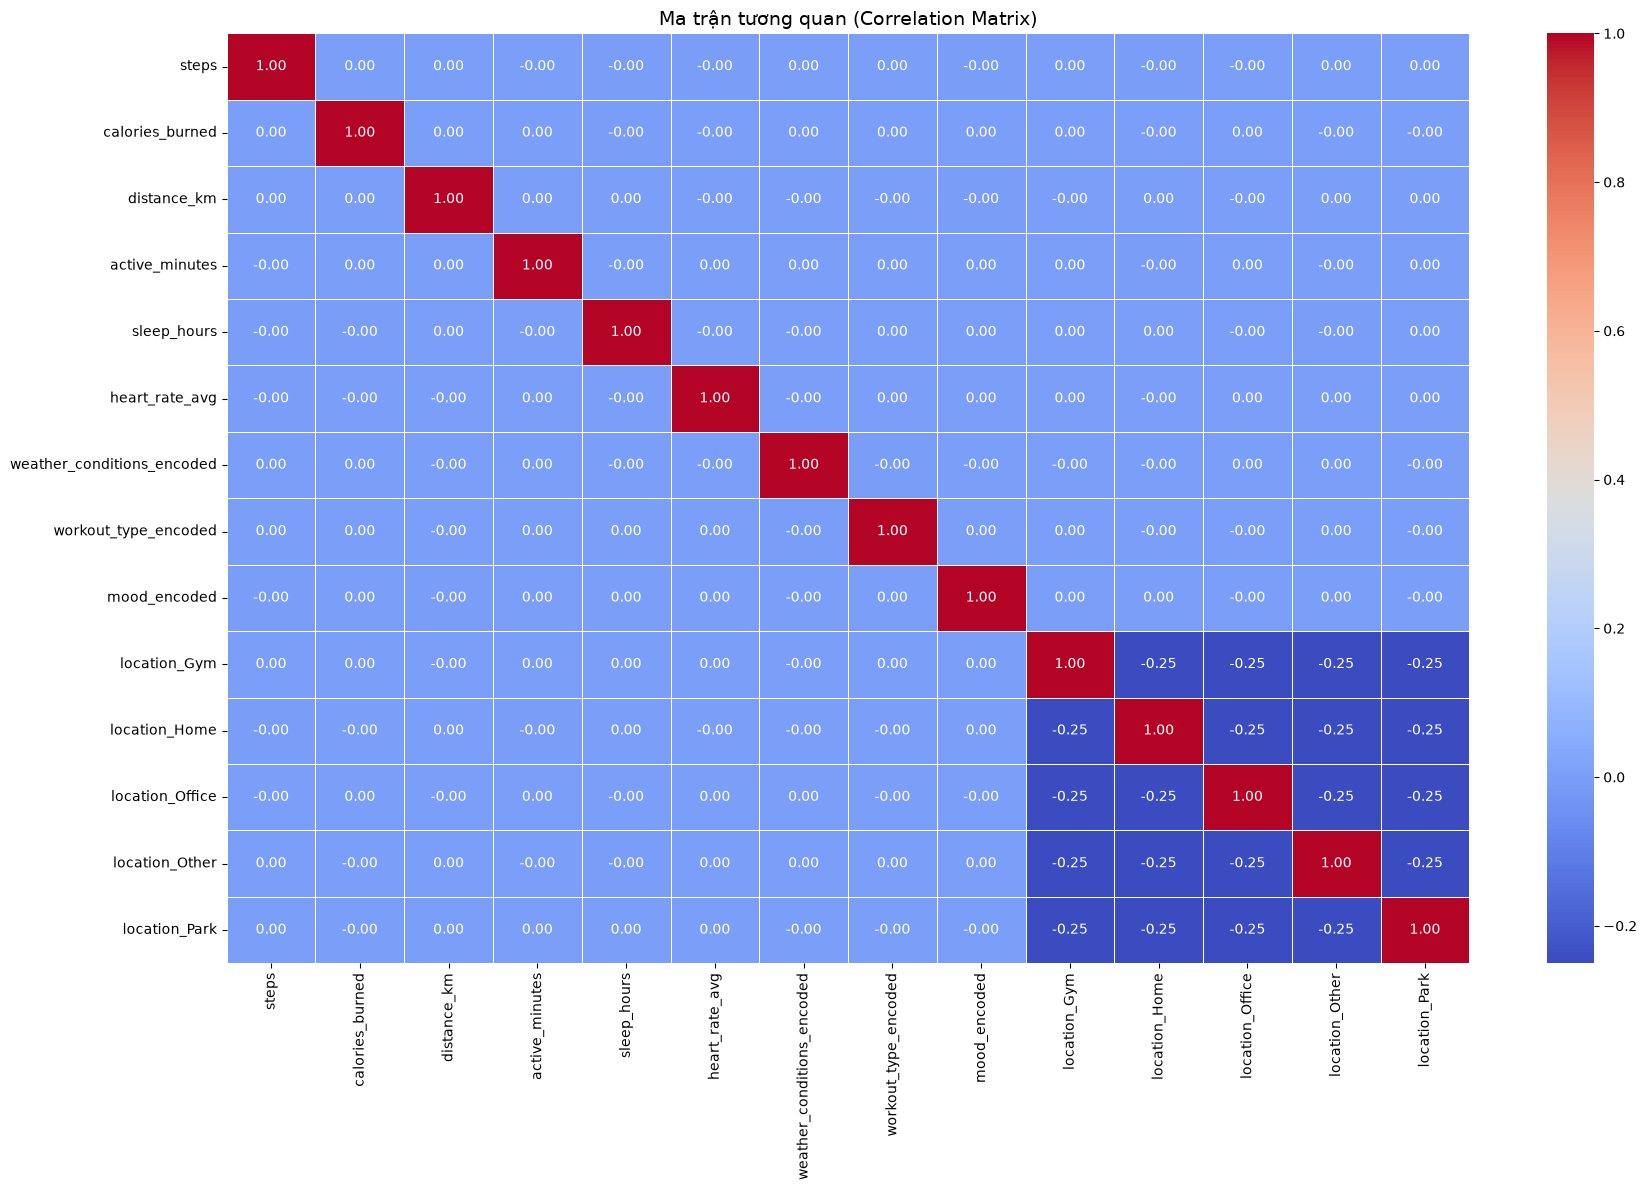

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Tính toán ma trận tương quan (chỉ áp dụng trên các cột dạng số)
corr_matrix = df.corr()
print("Ma trận tương quan:\n", corr_matrix)


# 4. Vẽ biểu đồ Heatmap bằng Seaborn
plt.figure(figsize=(18, 12)) # Thiết lập kích thước khung hình

# annot=True: Hiển thị con số trên từng ô
# cmap='coolwarm': Chọn dải màu (đỏ là tương quan dương, xanh là tương quan âm)
# fmt='.2f': Làm tròn đến 2 chữ số thập phân
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Ma trận tương quan (Correlation Matrix)', fontsize=14)
plt.tight_layout()
plt.show()

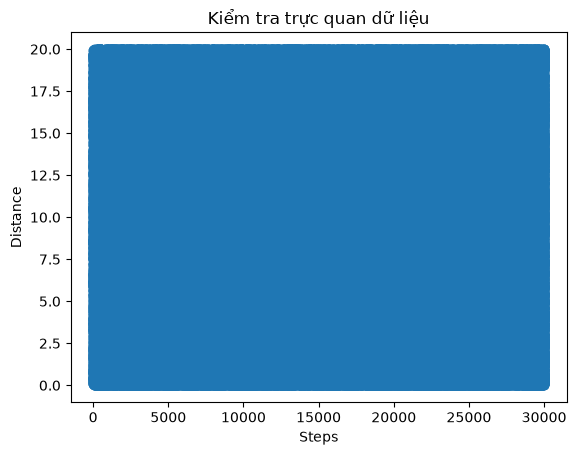

Index có bị trùng lặp không? True
Số dòng mất dữ liệu (NaN): 0


In [7]:
# 1. Kiểm tra mối quan hệ thực tế giữa các biến số tự nhiên
import matplotlib.pyplot as plt

plt.scatter(df['steps'], df['distance_km'])
plt.xlabel('Steps')
plt.ylabel('Distance')
plt.title('Kiểm tra trực quan dữ liệu')
plt.show()

# 2. Kiểm tra xem dữ liệu có bị trượt Index hay không
print("Index có bị trùng lặp không?", df.index.has_duplicates)
print("Số dòng mất dữ liệu (NaN):", df.isnull().sum().sum())

# train models

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def prepare_insurance_data(df, target_col='calories_burned'):
    """
    Chia tập dữ liệu, chọn lọc feature trên tập X_train, sau đó chuẩn hóa (scale).
    """
    df_processed = df.copy()

    # Lên danh sách các cột cần loại bỏ an toàn
    drop_cols = [target_col]

    # Phân tách X và y
    X = df_processed.drop(columns=drop_cols)
    y = df_processed[target_col]

    # Chia Train/Test/val (90/10/10)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42
    )
    X_train, X_eval, y_train, y_eval = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42
    )

    # Chuẩn hóa dữ liệu bằng StandardScaler
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
    X_eval_scaled = pd.DataFrame(scaler.transform(X_eval), index=X_eval.index, columns=X_eval.columns)

    return (X_train_scaled, X_test_scaled, X_eval_scaled,
            y_train, y_test, y_eval)

if __name__ == '__main__':
    
    # Chạy hàm chính
    results = prepare_insurance_data(df, target_col='calories_burned')
    
    # Giải nén kết quả
    X_train, X_test, X_eval, y_train, y_test, y_eval = results

    print("\n--- KẾT QUẢ ---")
    print(f'Train shape: {X_train.shape}')
    print(f'Test shape: {X_test.shape}')
    print(f'Evaluation shape: {X_eval.shape}')


--- KẾT QUẢ ---
Train shape: (805969, 13)
Test shape: (99503, 13)
Evaluation shape: (89553, 13)


In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB

In [31]:
##Create a Function to Evaluate Model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "SVR": SVR(), # Sửa tên cho chuẩn
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Adaboost Regressor": AdaBoostRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(), # Sửa lỗi chính tả
    "XGBoost Regressor": XGBRegressor()
}

# Tạo dictionary để lưu lại điểm số của các mô hình
eval_r2_scores = {}
eval_mse_scores = {}

# Cách lặp qua dictionary chuẩn Python
for name, model in models.items():
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_eval_pred = model.predict(X_eval)
    
    # Evaluate Train and Test dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_eval_mae, model_eval_mse, model_eval_rmse, model_eval_r2 = evaluate_model(y_eval, y_eval_pred)

    # Lưu kết quả test vào dictionary
    eval_r2_scores[name] = model_eval_r2
    eval_mse_scores[name] = model_eval_mse

    # In kết quả
    print(name)
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Squared Error: {:.4f}".format(model_train_mse)) # Đã bỏ **2
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for eval set')
    print("- Root Mean Squared Error: {:.4f}".format(model_eval_rmse))
    print("- Mean Squared Error: {:.4f}".format(model_eval_mse)) # Đã sửa lại thành in MSE
    print("- Mean Absolute Error: {:.4f}".format(model_eval_mae))
    print("- R2 Score: {:.4f}".format(model_eval_r2))
    
    print('='*35)
    print('\n')

eval_r2_scores = dict(sorted(eval_r2_scores.items(), key=lambda item: item[1], reverse=True))
eval_mse_scores = dict(sorted(eval_mse_scores.items(), key=lambda item: item[1]))

# ... (Phần code train và in kết quả phía trên của bạn giữ nguyên) ...

# Sắp xếp R2 giảm dần (càng cao càng tốt) và MSE tăng dần (càng thấp càng tốt)
eval_r2_scores = dict(sorted(eval_r2_scores.items(), key=lambda item: item[1], reverse=True))
eval_mse_scores = dict(sorted(eval_mse_scores.items(), key=lambda item: item[1]))

# Lấy ra Top 3 từ dictionary đã sắp xếp
top3_r2 = list(eval_r2_scores.items())[:3]
top3_mse = list(eval_mse_scores.items())[:3]

print("🏆 KẾT QUẢ TỔNG KẾT:")

print("Top 3 mô hình có R2 Score cao nhất:")
for rank, (model, score) in enumerate(top3_r2, 1):
    print(f"  {rank}. {model}: {score:.4f}")

print("-" * 35)

print("Top 3 mô hình có MSE thấp nhất:")
for rank, (model, score) in enumerate(top3_mse, 1):
    print(f"  {rank}. {model}: {score:.4f}")

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 721.5470
- Mean Squared Error: 520630.1015
- Mean Absolute Error: 624.7160
- R2 Score: 0.0000
----------------------------------
Model performance for eval set
- Root Mean Squared Error: 722.5091
- Mean Squared Error: 522019.4183
- Mean Absolute Error: 625.6870
- R2 Score: -0.0001


Lasso
Model performance for Training set
- Root Mean Squared Error: 721.5514
- Mean Squared Error: 520636.3576
- Mean Absolute Error: 624.7193
- R2 Score: 0.0000
----------------------------------
Model performance for eval set
- Root Mean Squared Error: 722.4936
- Mean Squared Error: 521996.9387
- Mean Absolute Error: 625.6715
- R2 Score: -0.0000


Ridge
Model performance for Training set
- Root Mean Squared Error: 721.5470
- Mean Squared Error: 520630.1015
- Mean Absolute Error: 624.7160
- R2 Score: 0.0000
----------------------------------
Model performance for eval set
- Root Mean Squared Error: 722.5091
- Mean Squared Error